some try error

In [1]:
import xarray as xr

ds = xr.open_dataset(r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250807\H14M48S16\XTomography_20250807144841.nc")
ds = xr.open_dataset(r"C:\Users\ASUS\Downloads\tomo\tomo\#599_LCH_NXX_182428_0\ds_raw.h5")
print(ds)

<xarray.Dataset> Size: 8kB
Dimensions:    (idle_time: 301, basis: 3, qubit: 1)
Coordinates:
  * idle_time  (idle_time) int32 1kB 0 1 2 3 4 5 6 ... 295 296 297 298 299 300
  * basis      (basis) int32 12B 0 1 2
  * qubit      (qubit) object 8B 'q1'
Data variables:
    state      (qubit, idle_time, basis) float64 7kB ...


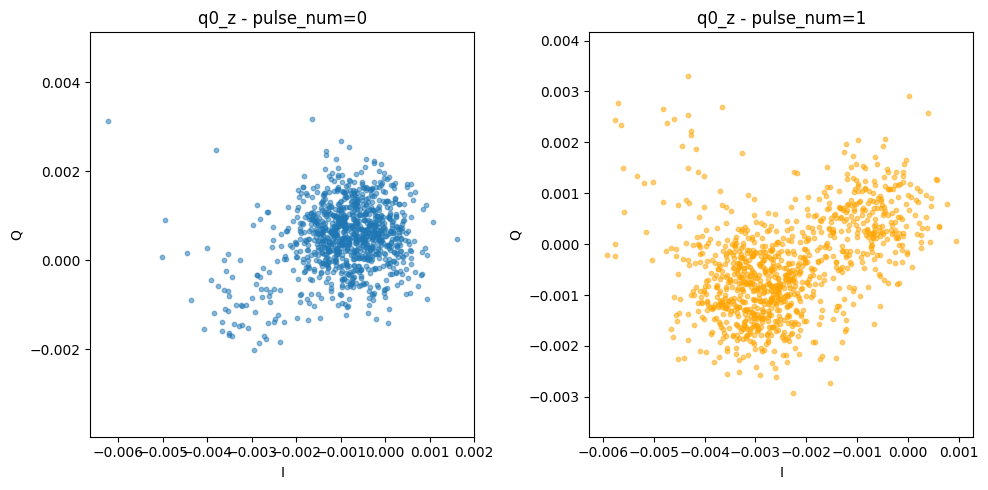

In [21]:
import xarray as xr
import matplotlib.pyplot as plt

# 讀檔
ds = xr.open_dataset(r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250811\H17M38S32\XTomography_20250811173914.nc")

# 取出 q0_z
q0_z = ds["q0_z"]  # shape: (mixer, pulse_num, index)

# pulse_num = 0 與 1 的 IQ 資料
I0 = q0_z.sel(mixer="I", pulse_num=0).values
Q0 = q0_z.sel(mixer="Q", pulse_num=0).values

I1 = q0_z.sel(mixer="I", pulse_num=1).values
Q1 = q0_z.sel(mixer="Q", pulse_num=1).values

# 畫圖
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# pulse_num = 0
axes[0].scatter(I0, Q0, s=10, alpha=0.5)
axes[0].set_title("q0_z - pulse_num=0")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Q")
axes[0].axis("equal")

# pulse_num = 1
axes[1].scatter(I1, Q1, s=10, alpha=0.5, color="orange")
axes[1].set_title("q0_z - pulse_num=1")
axes[1].set_xlabel("I")
axes[1].set_ylabel("Q")
axes[1].axis("equal")

plt.tight_layout()
plt.show()


In [23]:
import numpy as np

# Create a 1D NumPy array
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

# Reshape to a 2x3 matrix
reshaped_arr_2x3 = arr.reshape(2, 2, 3)
print("Reshaped to 2x3:\n", reshaped_arr_2x3)

# Reshape to a 3x2 matrix, letting NumPy infer one dimension
reshaped_arr_3x2 = arr.reshape(-1, 2)
print("\nReshaped to 3x2 (inferred rows):\n", reshaped_arr_3x2)

Reshaped to 2x3:
 [[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

Reshaped to 3x2 (inferred rows):
 [[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]


In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 讀取 CSV 資料
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
df = pd.read_csv(file_path)

# 將比例轉換為期望值範圍 [-1, 1]
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# Pauli matrices
I = np.eye(2)
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 將期望值轉換為 density matrix
def build_density_matrix(x, y, z):
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(x, y, z) for x, y, z in zip(X_exp, Y_exp, Z_exp)]



# 儲存 h 向量
hx_list, hy_list, hz_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 旋轉 rho_n
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated

    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 建立係數矩陣 M[k, j] = Tr(-i [σ_j, ρ_n] ⋅ σ_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real  # 這裡順序正確！

    # 解線性方程 M h = v
    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])
    
    # lambda_reg = 1e-3  # 正則化強度，可微調
    # try:
    #     h_vector = np.linalg.solve(M.T @ M + lambda_reg * np.eye(3), M.T @ v)
    # except Exception:
    #     h_vector = np.array([np.nan, np.nan, np.nan])

    # U, S, Vh = np.linalg.svd(M)
    # S_inv = np.array([1/s if s > 1e-6 else 0 for s in S])
    # M_pinv = Vh.T @ np.diag(S_inv) @ U.T
    # h_vector = M_pinv @ v


    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

# 繪圖
# fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# x_axis = df["Gate Num"].values[1:]

# ax[0].bar(x_axis, hx_list, color='r')
# ax[0].set_ylabel("h_x")
# ax[0].set_title("Hamiltonian Distribution")

# ax[1].bar(x_axis, hy_list, color='g')
# ax[1].set_ylabel("h_y")

# ax[2].bar(x_axis, hz_list, color='b')
# ax[2].set_ylabel("h_z")
# ax[2].set_xlabel("Gate Number")

# plt.tight_layout()
# plt.show()


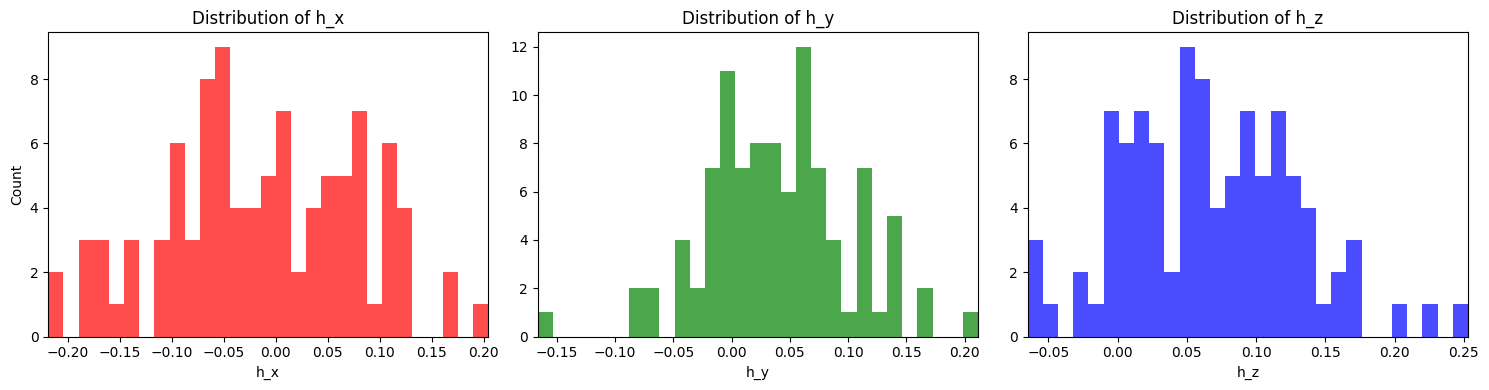

In [159]:

# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()


In [160]:
h = hx_list[1]*sigma_x + hy_list[1]*sigma_y + hz_list[1]*sigma_z 
print(h)
delta = -1j* (h @ density_matrices[1] - density_matrices[1] @ h)
print(delta)
delta2 = density_matrices[2] - sigma_x @ density_matrices[1] @ sigma_x
print(delta2)



[[ 0.00576289+0.j         -0.09015668+0.03593413j]
 [-0.09015668-0.03593413j -0.00576289+0.j        ]]
[[ 0.00652786-0.j          0.01925594+0.04726515j]
 [ 0.01925594-0.04726515j -0.00652786+0.j        ]]
[[-0.027+0.j     0.019+0.052j]
 [ 0.019-0.052j  0.027+0.j   ]]


In [161]:
import numpy as np
import matplotlib.pyplot as plt

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 存放結果
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

# 主迴圈：對每個相鄰的 rho_n, rho_{n+1} 做分析
for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated

    # 計算 RHS: v_k = Tr(delta_rho ⋅ sigma_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 計算 M[k, j] = Tr(-i [sigma_j, rho_n] ⋅ sigma_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real

    # 解 h_vector: M h = v
    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])

    hx, hy, hz = h_vector
    hx_list.append(hx)
    hy_list.append(hy)
    hz_list.append(hz)

    # 重建 h
    h = hx * sigma_x + hy * sigma_y + hz * sigma_z

    # 計算 coherent 演化的部分
    delta_rho_coh = -1j * (h @ rho_n - rho_n @ h)

    # decoherent 部分 = 真實誤差 - coherent 解釋部分
    delta_rho_decoh = delta_rho - delta_rho_coh

    # 計算誤差大小（Frobenius norm）
    coh_error = np.linalg.norm(delta_rho_coh, ord='fro')
    decoh_error = np.linalg.norm(delta_rho_decoh, ord='fro')
    total_error = np.linalg.norm(delta_rho, ord='fro')

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


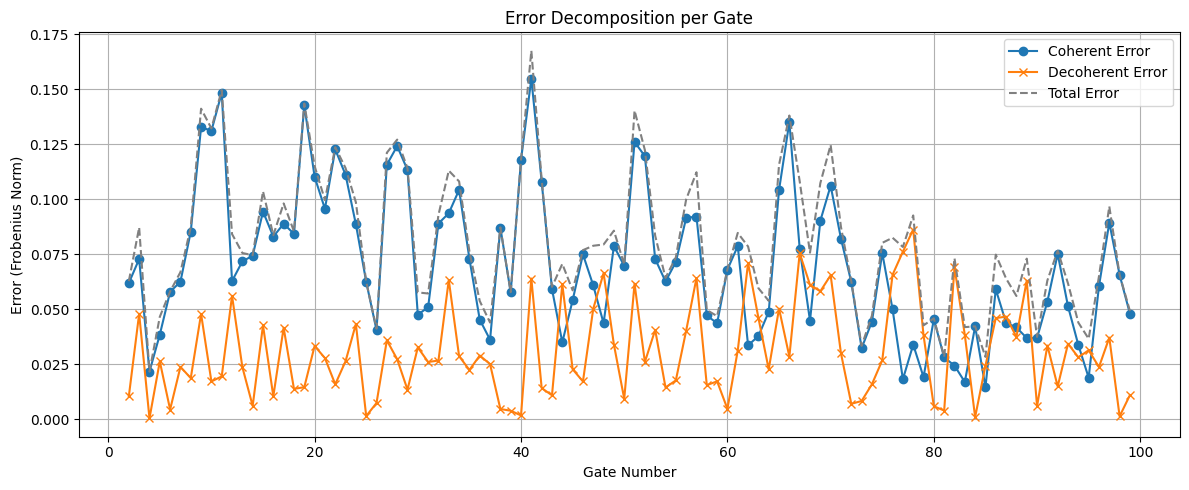

In [162]:
import matplotlib.pyplot as plt

x_axis = df["Gate Num"].values[1:]

plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='Decoherent Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

# === Step 2: 分析 Hamiltonian 與 Coherence/Decoherence ===
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 建立係數矩陣 M[k, j] = Tr(-i [σ_j, ρ_n] ⋅ σ_k)
    M = np.zeros((3, 3))
    for k, sigma_k in enumerate(paulis):
        for j, sigma_j in enumerate(paulis):
            comm = sigma_j @ rho_n - rho_n @ sigma_j
            M[k, j] = np.trace(-1j * comm @ sigma_k).real

    try:
        h_vector, *_ = np.linalg.lstsq(M, v, rcond=None)
    except Exception:
        h_vector = np.array([np.nan, np.nan, np.nan])

    hx, hy, hz = h_vector
    hx_list.append(hx)
    hy_list.append(hy)
    hz_list.append(hz)

    h = hx * sigma_x + hy * sigma_y + hz * sigma_z
    delta_rho_coh = -1j * (h @ rho_n - rho_n @ h)
    delta_rho_decoh = delta_rho - delta_rho_coh

    coh_error = np.linalg.norm(delta_rho_coh, ord='fro')
    decoh_error = np.linalg.norm(delta_rho_decoh, ord='fro')
    total_error = np.linalg.norm(delta_rho, ord='fro')

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


In [293]:

import numpy as np

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 初始態為 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])

# 建立旋轉矩陣：U(θ) = exp(-i θ/2 σ_x)
def rotation_x(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_x
def rotation_y(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_y
def rotation_z(theta):
    return np.cos(theta / 2) * np.eye(2) - 1j * np.sin(theta / 2) * sigma_z
# 生成密度矩陣列表
num_points = 99
angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
density_matrices = []

for theta in angles:
    U = rotation_y(theta)
    rho = U @ rho_0 @ U.conj().T
    density_matrices.append(rho)

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = rho_n

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)
bloch_vectors = []

for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)

# with XX gates flip


generate some Hamiltonian distribution to simulate density matrices' change.

In [24]:
import numpy as np
from scipy.linalg import expm

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 參數設定
N = 1000  # 你想要幾個時間點
delta_t = 1.0  # 每一小段的時間長度
h_strength = 0.05  # 控制隨機 H 的幅度

# 初始態 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])
ket_plus = np.array([[1], [1]]) / np.sqrt(2)
rho_plus = ket_plus @ ket_plus.conj().T

# |+i> = (|0> + i|1>) / sqrt(2)
ket_plus_i = np.array([[1], [1j]]) / np.sqrt(2)
rho_plus_i = ket_plus_i @ ket_plus_i.conj().T
# 儲存結果
hx_list, hy_list, hz_list = [], [], []
density_matrices = [rho_0]
bloch_vectors = []

# 隨機產生 h 向量（方向隨機，長度為 h_strength）
np.random.seed(42)  # 可重現性
h_vectors = h_strength * np.random.randn(N,3)
hx_strength = 0.01
hy_strength = 0.01
hz_strength = 1

# 時間步進模擬
for h in h_vectors:
    hx, hy, hz = h
    hx_list.append(hx*hx_strength)
    hy_list.append(hy*hy_strength)
    hz_list.append(hz*hz_strength)

    H = hx * hx_strength * sigma_x + hy * hy_strength *  sigma_y + hz * hz_strength * sigma_z
    U = expm(-1j * delta_t * H)
    
    rho_prev = density_matrices[-1]
    rho_next = U @ sigma_x @ rho_prev @ sigma_x @ U.conj().T 
    density_matrices.append(rho_next)

# 移除多餘最後一個以外
density_matrices = density_matrices[:-1]

# Bloch vectors 對應
for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)


Using the simulation density matrices to calculate hamiltonian distribution.

In [20]:
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


let raw data convert to density matrices, and calculate hamiltonian distribution.

In [261]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
paulis = [sigma_x, sigma_y, sigma_z]

# 讀取 xarray 檔案
file_path = r"C:\Users\ASUS\Downloads\tomo\tomo\#599_LCH_NXX_182428_0\ds_raw.h5"
ds = xr.open_dataset(file_path)

# 取出 qubit 名稱（假設只有一個 qubit）
qubit_name = str(ds.qubit.values[0])

# 從 dataset 中取出 state array
# state 的 shape = (qubit, idle_time, basis)
state_data = ds["state"].sel(qubit=qubit_name).values  # shape: (idle_time, basis)

# 將 0,1,2 對應到 X, Y, Z 期望值
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(state_data[:, 0])  # basis=0 -> X
Y_exp = expectation_from_prob(state_data[:, 1])  # basis=1 -> Y
Z_exp = expectation_from_prob(state_data[:, 2])  # basis=2 -> Z

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\tomo\q0\q0_TomoGateErrorTest_20250709171242_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250815\H15M36S05\q1_TomoGateErrorTest_20250815155833_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250815\H16M29S38\q1_TomoGateErrorTest_20250815172330_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

In [7]:


# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)

draw hamiltonian distribution

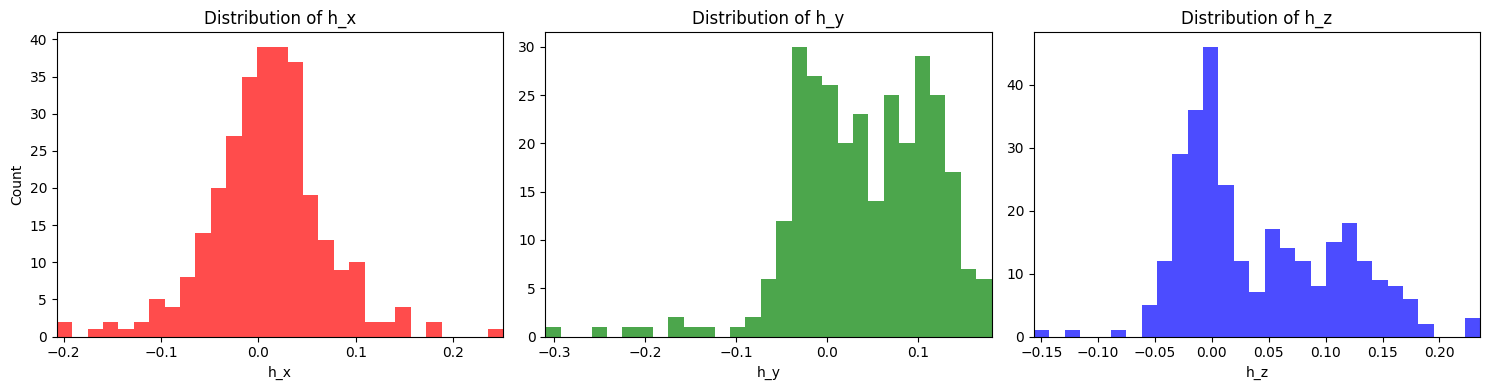

x_mean = 0.008336995530467748
y_mean = 0.04069298445657689
z_mean = 0.04075864240756669
x_std = 0.05888625863827669
y_std = 0.07476121798694496
z_std = 0.06777575290654123


In [254]:
%matplotlib inline
# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()
print(f"x_mean = {np.mean(hx_clean)}")
print(f"y_mean = {np.mean(hy_clean)}")
print(f"z_mean = {np.mean(hz_clean)}")
print(f"x_std = {np.std(hx_clean)}")
print(f"y_std = {np.std(hy_clean)}")
print(f"z_std = {np.std(hz_clean)}")

some calculate checking (not important)

處理檔案: C:\Users\ASUS\Downloads\tomo\tomo\#599_LCH_NXX_182428_0\ds_raw.h5
hx_all shape: (300,)
hy_all shape: (300,)
hz_all shape: (300,)


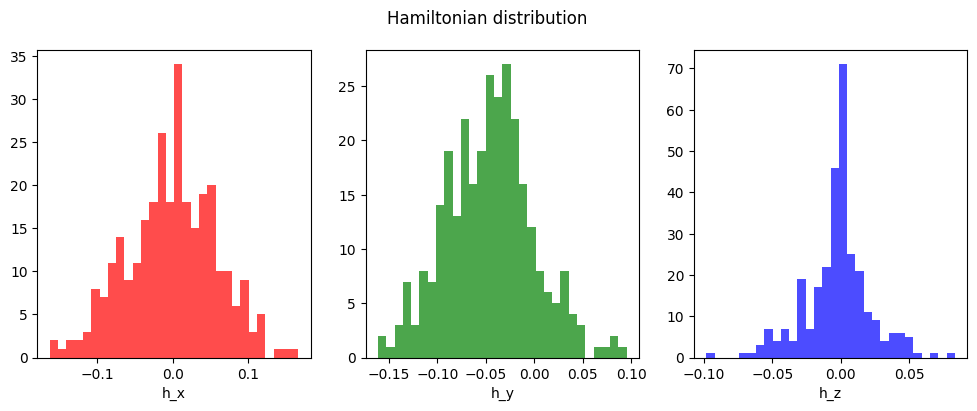

x_mean = -0.0009690602245593138
y_mean = -0.045815276995800576
z_mean = -0.0023627012978792387
x_std = 0.05922587544247893
y_std = 0.04509603517470924
z_std = 0.023623516884406323


In [217]:
import numpy as np
import xarray as xr
%matplotlib inline
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
paulis = [sigma_x, sigma_y, sigma_z]

def expectation_from_prob(p):
    return 2 * p - 1

def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

def process_file_for_h(file_path):
    """處理單一檔案，計算 hx, hy, hz"""
    ds = xr.open_dataset(file_path)

    all_h = []

    for qb in ds.qubit.values:
        state_data = ds["state"].sel(qubit=qb).values  # (idle_time, basis)

        X_exp = expectation_from_prob(state_data[:, 0])
        Y_exp = expectation_from_prob(state_data[:, 1])
        Z_exp = expectation_from_prob(state_data[:, 2])

        bloch_vectors = []
        for x, y, z in zip(X_exp, Y_exp, Z_exp):
            r = np.array([x, y, z], dtype=float)
            norm = np.linalg.norm(r)
            if norm > 1e-8:
                r_proj = r / norm
            else:
                r_proj = np.array([0.0, 0.0, 1.0])
            bloch_vectors.append(r_proj)

        density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

        hx_list, hy_list, hz_list = [], [], []

        for n in range(len(density_matrices) - 1):
            rho_n = density_matrices[n]
            rho_np1 = density_matrices[n + 1]

            # 理想 X 門演化
            rotated = sigma_x @ rho_n @ sigma_x
            delta_rho = rho_np1 - rotated

            v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])
            r_vec = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

            # h = r × v 逆運算 (根據 v = h × r)
            if np.linalg.norm(r_vec) > 1e-8:
                h_vec =1/2* np.cross(r_vec,v) / (np.linalg.norm(r_vec)**2)
            else:
                h_vec = np.array([np.nan, np.nan, np.nan])

            hx_list.append(h_vec[0])
            hy_list.append(h_vec[1])
            hz_list.append(h_vec[2])

        all_h.append({
            "qubit": str(qb),
            "hx": np.array(hx_list),
            "hy": np.array(hy_list),
            "hz": np.array(hz_list)
        })

    return all_h

# === 多檔案處理 ===
file_paths = [
    r"C:\Users\ASUS\Downloads\tomo\tomo\#599_LCH_NXX_182428_0\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#604_LCH_NXX_183747_0\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#605_LCH_NXX_184014_0\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#606_LCH_NXX_184320_0\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#607_LCH_NXX_184523_0\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#600_LCH_NXX_182646_y90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#608_LCH_NXX_184729_y90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#609_LCH_NXX_184926_y90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#602_LCH_NXX_183125_-x90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#610_LCH_NXX_185128_-x90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#611_LCH_NXX_185327_-x90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#601_LCH_NXX_182855_x90\ds_raw.h5",
    # r"C:\Users\ASUS\Downloads\tomo\tomo\#603_LCH_NXX_183422_-y90\ds_raw.h5"
]

all_h_data = []
for fpath in file_paths:
    print(f"處理檔案: {fpath}")
    all_h_data.extend(process_file_for_h(fpath))

# 將所有 h 向量合併
hx_all = np.concatenate([d["hx"] for d in all_h_data])
hy_all = np.concatenate([d["hy"] for d in all_h_data])
hz_all = np.concatenate([d["hz"] for d in all_h_data])

print("hx_all shape:", hx_all.shape)
print("hy_all shape:", hy_all.shape)
print("hz_all shape:", hz_all.shape)

# 畫分布圖
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(hx_all, bins=30, alpha=0.7, color="r")
plt.xlabel("h_x")
plt.subplot(1, 3, 2)
plt.hist(hy_all, bins=30, alpha=0.7, color="g")
plt.xlabel("h_y")
plt.subplot(1, 3, 3)
plt.hist(hz_all, bins=30, alpha=0.7, color="b")
plt.xlabel("h_z")
plt.suptitle("Hamiltonian distribution")
plt.show()
print(f"x_mean = {np.mean(hx_all)}")
print(f"y_mean = {np.mean(hy_all)}")
print(f"z_mean = {np.mean(hz_all)}")
print(f"x_std = {np.std(hx_all)}")
print(f"y_std = {np.std(hy_all)}")
print(f"z_std = {np.std(hz_all)}")

In [49]:
h = hx_list[1]*sigma_x + hy_list[1]*sigma_y + hz_list[1]*sigma_z 

delta = -1j* (h @ density_matrices[1] - density_matrices[1] @ h)
delta_vector = np.array([np.trace(delta @ sigma_k).real for sigma_k in paulis])
print(delta_vector)

delta2 = density_matrices[2] - sigma_x @ density_matrices[1] @ sigma_x
delta_vector2 = np.array([np.trace(delta2 @ sigma_k).real for sigma_k in paulis])
print(delta_vector2)

h_vector_0 = np.array([np.trace(h @ sigma_k).real for sigma_k in paulis])
r_0 = np.array([np.trace(density_matrices[1] @ sigma_k).real for sigma_k in paulis])
print(np.cross(h_vector_0, r_0))

print(np.cross(r_0,delta_vector2))
print(h_vector_0)

np.dot(delta_vector2,r_0)


[-0.21491057 -0.12913599  0.00650612]
[-0.21498722 -0.13066901 -0.02645387]
[-0.21491057 -0.12913599  0.00650612]
[-0.12929846  0.21469302 -0.00968503]
[-0.12929846  0.21469302 -0.00968503]


0.03299570900770907

coherence error and fitting error par gates (need to change x_axis when you want to check simulation result)

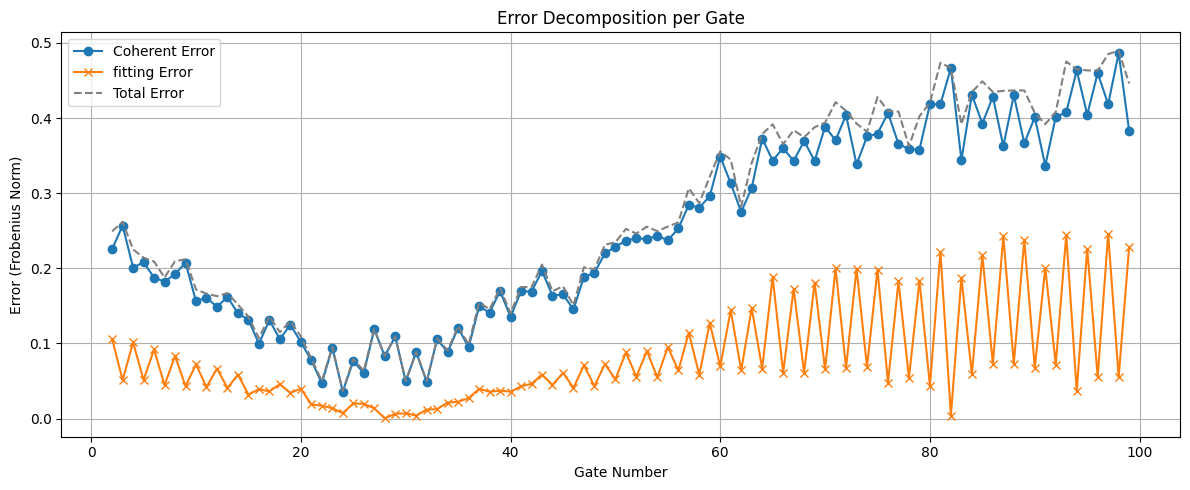

In [245]:
import matplotlib.pyplot as plt
%matplotlib inline
x_axis = df["Gate Num"].values[1:]
# x_axis = ds["idle_time"].values[1:]

plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='fitting Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


also not important checking

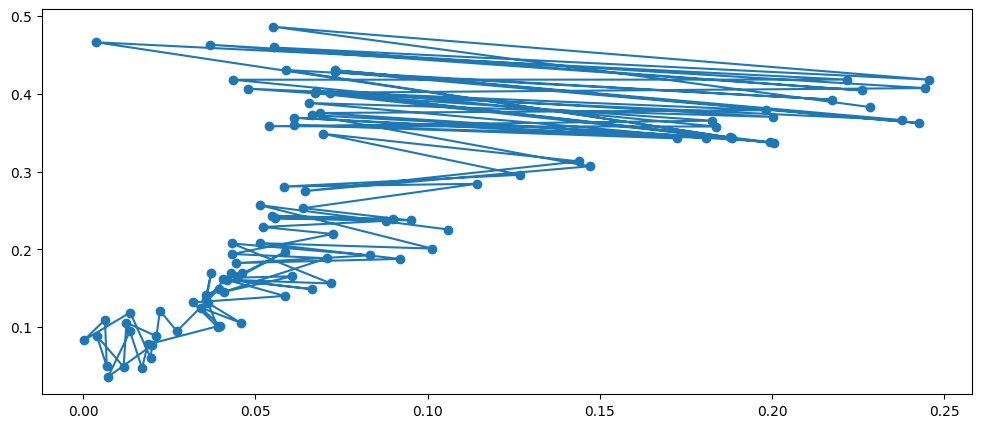

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(decoh_error_list, coh_error_list, label='Coherent Error', marker='o')
plt.show()


check the hamiltonian and some important vector in bloch sphere.

In [260]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib qt5
# 選擇某一筆資料進行可視化（例如第 n = 0 筆）
n_vis =81

rho_n = density_matrices[n_vis]
rho_np1 = density_matrices[n_vis + 1]
rotated = sigma_x @ rho_n @ sigma_x
delta_rho = rho_np1 - rotated

# Bloch vectors
rn = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
r = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])
r_1 = np.array([np.trace(rho_np1 @ sigma_k).real for sigma_k in paulis])
r_norm_sq = np.dot(r, r)
if r_norm_sq > 1e-8:
    h = 1/2 * np.cross(r, v) / r_norm_sq
else:
    h = np.array([0, 0, 0])

# ========== Plotting ==========
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Visualization of Bloch Vectors: r, v = h × r, and h")

# Draw Bloch sphere
u, v_sphere = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v_sphere)
y_sphere = np.sin(u) * np.sin(v_sphere)
z_sphere = np.cos(v_sphere)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# Origin
origin = np.zeros(3)

# Plot vectors
ax.quiver(*origin, *r, color='green', label=f'r_{n_vis}_rotated', linewidth=2)
ax.quiver(*origin, *v, color='red', label='v = Δr', linewidth=2)
ax.quiver(*origin, *h, color='blue', label='h (Hamiltonian vector)', linewidth=2)
ax.quiver(*origin, *r_1, color='yellow', label=f'r_{n_vis+1}',linewidth=2)
ax.quiver(*origin, *rn, color='black', label=f'r_{n_vis}',linewidth=2)
# Cross check vector identity (optional)
v_cross_check = 2 * np.cross(h, r)
ax.quiver(*origin, *v_cross_check, color='orange', linestyle='dashed', linewidth=1, label='h × r (check)')

# Axis limits
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Legend
ax.legend()
plt.tight_layout()
plt.show()
print(np.linalg.norm(h))
print(np.linalg.norm(v))

0.08990032185291642
0.18053770084867118


density metrices in bloch sphere

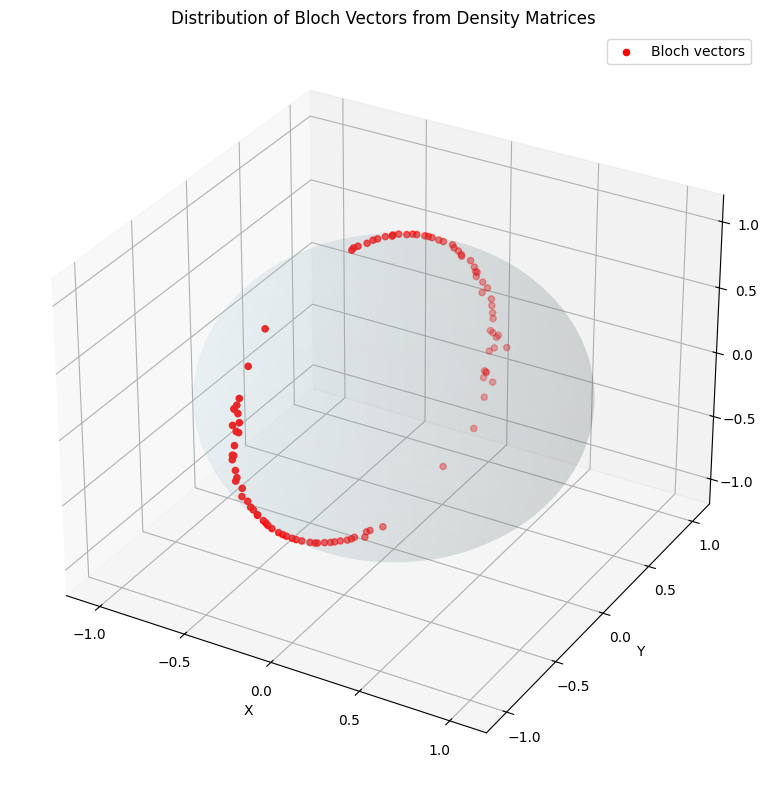

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib inline
# 擷取 bloch_vectors 的 x, y, z 元素

bloch_array = np.array(bloch_vectors)
x_vals, y_vals, z_vals = bloch_array[:, 0], bloch_array[:, 1], bloch_array[:, 2]

# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Distribution of Bloch Vectors from Density Matrices")

# 畫出 Bloch 球
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# 畫出 Bloch 向量分布
ax.scatter(x_vals, y_vals, z_vals, color='red', s=20, label='Bloch vectors')

# 設定視圖範圍與標籤
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


animation of evoluton

In [152]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
import numpy as np
%matplotlib qt5
# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.05, linewidth=0)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Bloch Vector Animation with Hamiltonian')

origin = np.zeros(3)

# 初始化為空（會在 update 中填入）
r_quiver = None
v_quiver = None
h_quiver = None
r_1_quiver = None

def update(n):
    global r_quiver, v_quiver, h_quiver, r_1_quiver

    # 移除前一個向量
    if r_quiver: r_quiver.remove()
    if v_quiver: v_quiver.remove()
    if h_quiver: h_quiver.remove()
    if r_1_quiver: r_1_quiver.remove()
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]
    rotated = sigma_x @ rho_n @ sigma_x
    delta_rho = rho_np1 - rotated
    r_1 = np.array([np.trace(rho_np1 @ sigma_k).real for sigma_k in paulis])
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    v_vec_arr = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    r_norm_sq = np.dot(r, r)
    h = 1/2*np.cross(r, v_vec_arr) / r_norm_sq if r_norm_sq > 1e-8 else np.zeros(3)

    # 畫新的向量
    r_1_quiver = ax.quiver(*origin, *r_1, color='yellow', linewidth=2)
    r_quiver = ax.quiver(*origin, *r, color='green', linewidth=2)
    v_quiver = ax.quiver(*origin, *v_vec_arr, color='red', linewidth=2)
    h_quiver = ax.quiver(*origin, *h, color='blue', linewidth=2)

    ax.set_title(f"Step {n} / {len(density_matrices)-2}")
    return r_quiver, v_quiver, h_quiver, r_1_quiver

ani = animation.FuncAnimation(fig, update, frames=len(density_matrices)-1, interval=500, blit=False)

# 如果你在非互動式環境，改用儲存
# ani.save("bloch_animation.mp4", writer="ffmpeg", fps=2)

plt.show()


## without xx gate flip


In [62]:
import numpy as np
from scipy.linalg import expm

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# 參數設定
N = 99  # 你想要幾個時間點
delta_t = 1.0  # 每一小段的時間長度
h_strength = 1  # 控制隨機 H 的幅度

# 初始態 |0⟩
rho_0 = np.array([[1, 0],
                  [0, 0]])

# 儲存結果
hx_list, hy_list, hz_list = [], [], []
density_matrices = [rho_0]
bloch_vectors = []

# 隨機產生 h 向量（方向隨機，長度為 h_strength）
# np.random.seed(42) 
np.random  # 可重現性
h_vectors = h_strength * np.random.randn(N,3)

# 時間步進模擬
for h in h_vectors:
    hx, hy, hz = h
    drift_amp = 0
    drift_angle = 0/360*np.pi*2
    drift_x = drift_amp*np.cos(drift_angle)
    drift_y = drift_amp*np.sin(drift_angle)
    hx_list.append(hx*0.07416751102773608+drift_x+0.02222095157769819)
    hy_list.append(hy*0.034498442525437156+drift_y-0.0008021855919747018)
    hz_list.append(hz*0.0560110020928766+0.0007401998962057134)

    H = (hx*0.07416751102773608+drift_x+0.02222095157769819) * sigma_x + (hy*0.034498442525437156+drift_y-0.0008021855919747018) *  sigma_y + (hz*0.0560110020928766+0.0007401998962057134) * sigma_z
    U = expm(-1j * delta_t * H)
    
    rho_prev = density_matrices[-1]
    rho_next = U @ rho_prev @ U.conj().T 
    density_matrices.append(rho_next)

# 移除多餘最後一個以外
density_matrices = density_matrices[:-1]

# Bloch vectors 對應
for rho in density_matrices:
    r = np.array([np.trace(rho @ sigma_k).real for sigma_k in paulis])
    bloch_vectors.append(r)


In [63]:
hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated =  rho_n 

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])

    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(np.cross(h_vector, r))
    decoh_error = np.linalg.norm(1/2*v - np.cross(h_vector, r))
    total_error = np.linalg.norm(1/2*v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


In [247]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250428\H10M22S46\q4_TomoGateErrorTest_20250428102913_TomoGateError.csv"
# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250421\H13M54S24\q2_TomoGateErrorTest_20250421140455_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250815\H16M29S38\q1_TomoGateErrorTest_20250815172330_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(1,len(density_matrices) - 2):
    rho_n = density_matrices[n]
    rho_np2 = density_matrices[n + 2]

    # 理想演化
    rotated = rho_n

    delta_rho = rho_np2 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)


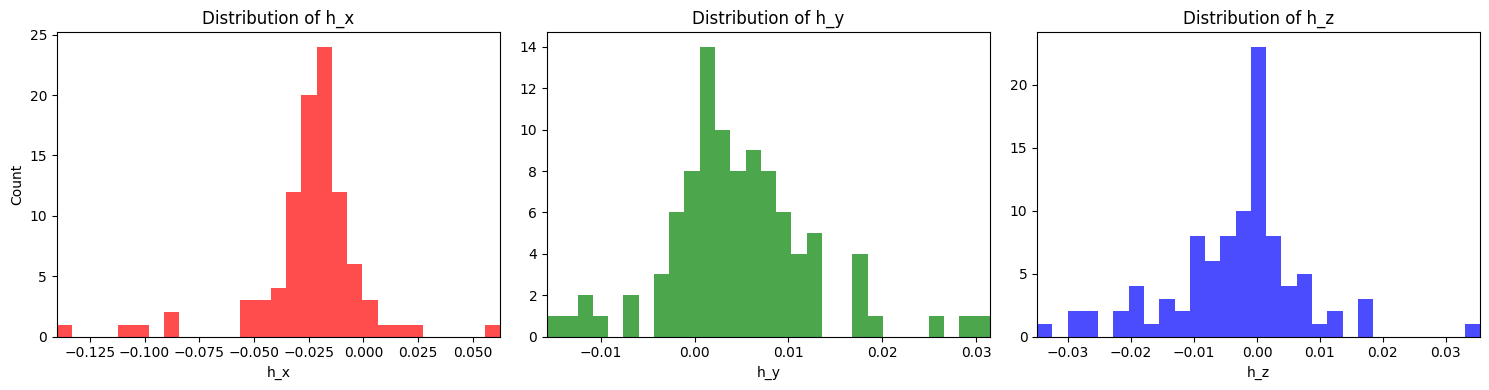

x_mean = -0.02445122945037785
y_mean = 0.0046436874909765
z_mean = -0.0032848917627687144
x_std = 0.024926446947731464
y_std = 0.007805226808245552
z_std = 0.010677854918571766


In [248]:
%matplotlib inline
# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()
print(f"x_mean = {np.mean(hx_clean)}")
print(f"y_mean = {np.mean(hy_clean)}")
print(f"z_mean = {np.mean(hz_clean)}")
print(f"x_std = {np.std(hx_clean)}")
print(f"y_std = {np.std(hy_clean)}")
print(f"z_std = {np.std(hz_clean)}")

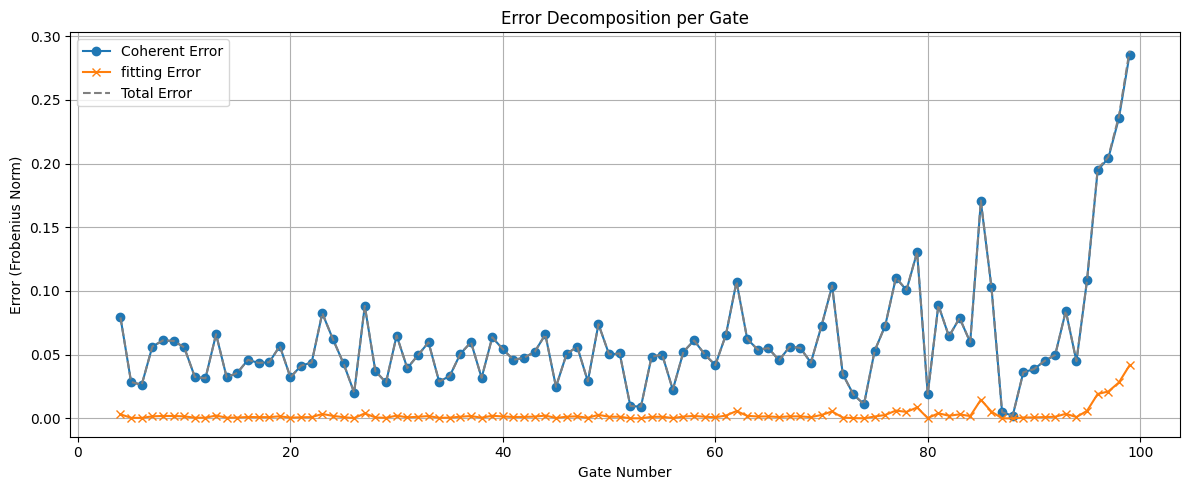

In [249]:
import matplotlib.pyplot as plt
%matplotlib inline
x_axis = df["Gate Num"].values[3:]
# x_axis = range(97)
plt.figure(figsize=(12, 5))
plt.plot(x_axis, coh_error_list, label='Coherent Error', marker='o')
plt.plot(x_axis, decoh_error_list, label='fitting Error', marker='x')
plt.plot(x_axis, total_error_list, label='Total Error', linestyle='--', color='gray')
plt.xlabel("Gate Number")
plt.ylabel("Error (Frobenius Norm)")
plt.title("Error Decomposition per Gate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [250]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib qt5
# 擷取 bloch_vectors 的 x, y, z 元素

bloch_array = np.array(bloch_vectors)
x_vals, y_vals, z_vals = bloch_array[:, 0], bloch_array[:, 1], bloch_array[:, 2]

# 建立 Bloch 球
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Distribution of Bloch Vectors from Density Matrices")

# 畫出 Bloch 球
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# 畫出 Bloch 向量分布
ax.scatter(x_vals, y_vals, z_vals, color='red', s=20, label='Bloch vectors')

# 設定視圖範圍與標籤
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


In [68]:
import numpy as np

A = np.array([[1, 3], [2, 6]])
A_pinv = np.linalg.pinv(A)

print("A^+ =", A_pinv)


A^+ = [[0.02 0.04]
 [0.06 0.12]]


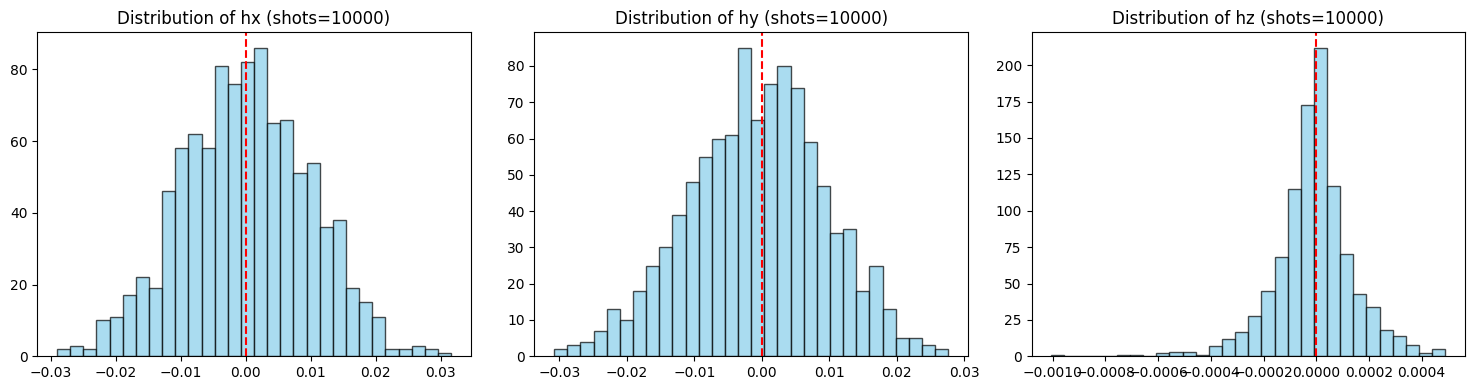

In [32]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# === 基本函數 ===
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

def measure_expectations(rho, shots=1000):
    """模擬有限shots的量測 (binomial noise)"""
    exps = []
    for sigma in paulis:
        p_plus = np.real(np.trace(rho @ (np.eye(2) + sigma) / 2))
        counts = np.random.binomial(shots, p_plus)
        p_est = counts / shots
        exp_est = 2 * p_est - 1
        exps.append(exp_est)
    return np.array(exps)

# === 模擬 X gate 演化 ===
def simulate_once(shots=1000):
    # 初始態 |0> = Z+
    rho_n = build_density_matrix(0, 0, 1)

    # 理想演化: X ρ X
    rotated = sigma_x @ rho_n @ sigma_x
    rho_np1 = rotated.copy()

    # 加入量測統計噪音
    r_n = measure_expectations(rho_n, shots=shots)
    r_np1 = measure_expectations(rho_np1, shots=shots)

    # 轉換成密度矩陣
    rho_n_noisy = build_density_matrix(*r_n)
    rho_np1_noisy = build_density_matrix(*r_np1)

    # 計算 delta_rho
    delta_rho = rho_np1_noisy - rotated

    # v 向量
    v = np.array([np.trace(delta_rho @ sigma).real for sigma in paulis])

    # r 向量
    r = np.array([np.trace(rho_n_noisy @ sigma).real for sigma in paulis])

    # 解 h × r = v
    # 注意: h = r × v / |r|^2 （最小二乘解）
    if np.linalg.norm(r) > 1e-8:
        h = np.cross(r, v) / (np.linalg.norm(r)**2)
    else:
        h = np.array([0.0, 0.0, 0.0])

    return h, r, v

# === 多次模擬以得到分布 ===
def simulate_distribution(num_trials=500, shots=1000):
    hs = []
    for _ in range(num_trials):
        h, r, v = simulate_once(shots=shots)
        hs.append(h)
    return np.array(hs)

# === 主程式 ===
shots = 10000   # 調整這裡試不同shots數量
num_trials = 1000

hs = simulate_distribution(num_trials=num_trials, shots=shots)

# 畫圖
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
labels = ["hx", "hy", "hz"]
for i in range(3):
    axs[i].hist(hs[:, i], bins=30, alpha=0.7, color="skyblue", edgecolor="k")
    axs[i].set_title(f"Distribution of {labels[i]} (shots={shots})")
    axs[i].axvline(0, color="r", linestyle="--")

plt.tight_layout()
plt.show()


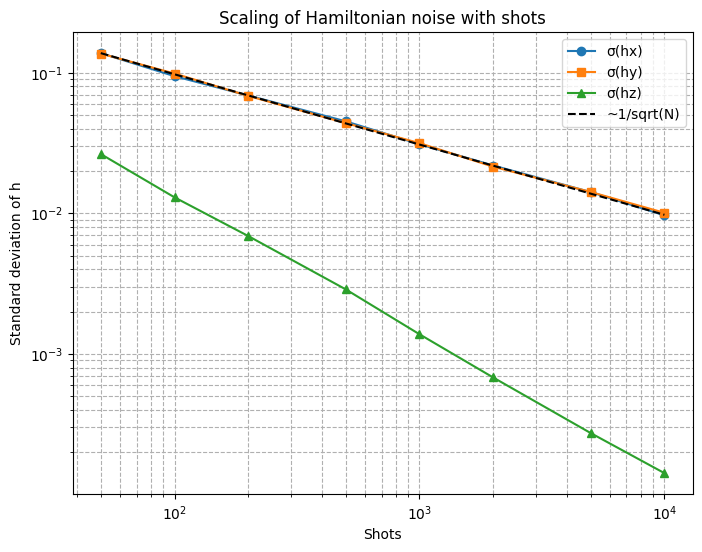

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

def measure_expectations(rho, shots=1000):
    exps = []
    for sigma in paulis:
        p_plus = np.real(np.trace(rho @ (np.eye(2) + sigma) / 2))
        counts = np.random.binomial(shots, p_plus)
        p_est = counts / shots
        exp_est = 2 * p_est - 1
        exps.append(exp_est)
    return np.array(exps)

def simulate_once(shots=1000):
    # 初始態 |0>
    rho_n = build_density_matrix(0, 0, 1)
    rotated = sigma_x @ rho_n @ sigma_x
    rho_np1 = rotated.copy()

    # 加入測量噪音
    r_n = measure_expectations(rho_n, shots=shots)
    r_np1 = measure_expectations(rho_np1, shots=shots)

    rho_n_noisy = build_density_matrix(*r_n)
    rho_np1_noisy = build_density_matrix(*r_np1)

    delta_rho = rho_np1_noisy - rotated
    v = np.array([np.trace(delta_rho @ sigma).real for sigma in paulis])
    r = np.array([np.trace(rho_n_noisy @ sigma).real for sigma in paulis])

    if np.linalg.norm(r) > 1e-8:
        h = np.cross(r, v) / (np.linalg.norm(r) ** 2)
    else:
        h = np.array([0.0, 0.0, 0.0])
    return h

def simulate_distribution(num_trials=500, shots=1000):
    hs = []
    for _ in range(num_trials):
        hs.append(simulate_once(shots=shots))
    return np.array(hs)

# === 掃描不同 shots 數 ===
shot_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
num_trials = 1000
stds_hx, stds_hy, stds_hz = [], [], []

for shots in shot_list:
    hs = simulate_distribution(num_trials=num_trials, shots=shots)
    stds_hx.append(np.std(hs[:,0]))
    stds_hy.append(np.std(hs[:,1]))
    stds_hz.append(np.std(hs[:,2]))

# === 畫圖 ===
plt.figure(figsize=(8,6))
plt.loglog(shot_list, stds_hx, 'o-', label="σ(hx)")
plt.loglog(shot_list, stds_hy, 's-', label="σ(hy)")
plt.loglog(shot_list, stds_hz, '^-', label="σ(hz)")

# 理論 scaling ~ 1/sqrt(N)
theory = stds_hx[0] * np.sqrt(shot_list[0]) / np.sqrt(np.array(shot_list))
plt.loglog(shot_list, theory, 'k--', label="~1/sqrt(N)")

plt.xlabel("Shots")
plt.ylabel("Standard deviation of h")
plt.title("Scaling of Hamiltonian noise with shots")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


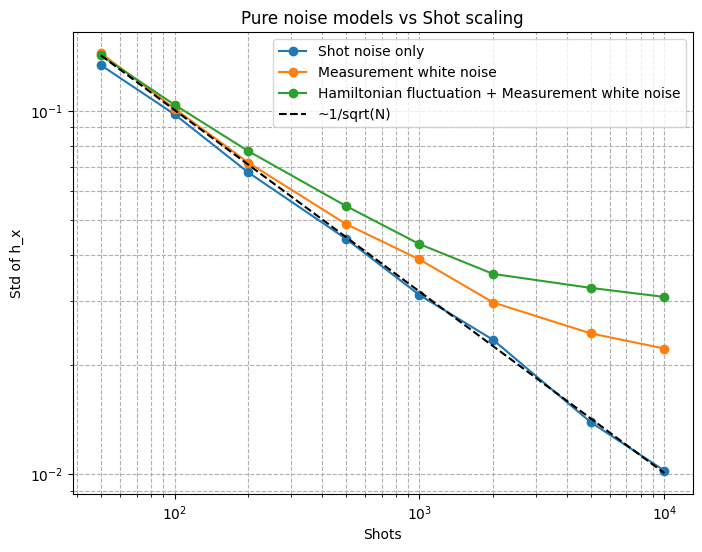

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

def measure_expectations(rho, shots=1000, noise_type=None, noise_strength=0.0):
    exps = []
    for sigma in paulis:
        p_plus = np.real(np.trace(rho @ (np.eye(2) + sigma) / 2))
        p_plus = np.clip(p_plus, 0, 1)  # 防止 NaN 或超界

        counts = np.random.binomial(shots, p_plus)
        p_est = counts / shots
        exp_est = 2 * p_est - 1

        # Measurement noise
        if noise_type == "meas":
            exp_est += np.random.normal(0, noise_strength)
            exp_est = np.clip(exp_est, -1, 1)
        if noise_type == "ham + meas":
            exp_est += np.random.normal(0, noise_strength)
            exp_est = np.clip(exp_est, -1, 1)
        exps.append(exp_est)
    return np.array(exps)

def simulate_once(shots=1000, noise_type=None, noise_strength=0.0):
    # 初始態 |0>
    rho_n = build_density_matrix(0, 0, 1)

    # Preparation noise
    if noise_type == "prep":
        delta = np.random.normal(0, noise_strength, size=3)
        rho_n = build_density_matrix(*(np.array([0,0,1]) + delta))

    # Hamiltonian fluctuation noise (random overrotation)
    theta = np.pi
    if noise_type == "ham":
        theta += np.random.normal(0, noise_strength)
    if noise_type == "ham + meas":
        theta += np.random.normal(0, noise_strength)
    U = np.cos(theta/2)*np.eye(2) - 1j*np.sin(theta/2)*sigma_x
    idle_U = - 1j*np.sin(np.pi/2)*sigma_x
    rotated = U @ rho_n @ U.conj().T
    idle_rotated = idle_U @ rho_n @ idle_U.conj().T
    rho_np1 = rotated.copy()

    # 測量 + 測量噪聲
    r_n = measure_expectations(rho_n, shots=shots, noise_type=noise_type, noise_strength=noise_strength)
    r_np1 = measure_expectations(rho_np1, shots=shots, noise_type=noise_type, noise_strength=noise_strength)

    rho_n_noisy = build_density_matrix(*r_n)
    rho_np1_noisy = build_density_matrix(*r_np1)

    delta_rho = rho_np1_noisy - idle_rotated
    v = np.array([np.trace(delta_rho @ sigma).real for sigma in paulis])
    r = np.array([np.trace(rho_n_noisy @ sigma).real for sigma in paulis])

    if np.linalg.norm(r) > 1e-8:
        h = np.cross(r, v) / (np.linalg.norm(r) ** 2)
    else:
        h = np.array([0.0, 0.0, 0.0])
    return h

def simulate_distribution(num_trials=500, shots=1000, noise_type=None, noise_strength=0.0):
    hs = []
    for _ in range(num_trials):
        hs.append(simulate_once(shots=shots, noise_type=noise_type, noise_strength=noise_strength))
    return np.array(hs)

# === 掃描不同 shots 數 ===
shot_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
num_trials = 1000
noise_strength = 0.02  # 控制雜訊強度

noise_cases = {
    "Shot noise only": (None, 0.0),
    "Measurement white noise": ("meas", noise_strength),
    # "Preparation noise": ("prep", noise_strength),
    # "Hamiltonian fluctuation": ("ham", noise_strength),
    "Hamiltonian fluctuation + Measurement white noise": ("ham + meas", noise_strength),
}

plt.figure(figsize=(8,6))
for label, (noise_type, ns) in noise_cases.items():
    stds_hx = []
    for shots in shot_list:
        hs = simulate_distribution(num_trials=num_trials, shots=shots,
                                   noise_type=noise_type, noise_strength=ns)
        stds_hx.append(np.std(hs[:,0]))
    plt.loglog(shot_list, stds_hx, 'o-', label=label)

# 理論 shot noise scaling
theory = stds_hx[0] * np.sqrt(shot_list[0]) / np.sqrt(np.array(shot_list))
plt.loglog(shot_list, theory, 'k--', label="~1/sqrt(N)")

plt.xlabel("Shots")
plt.ylabel("Std of h_x")
plt.title("Pure noise models vs Shot scaling")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [181]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib qt5
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

def unitary_x_gate(Omega, Delta, t_gate):
    """
    單次 X gate 的演化算符
    H = Δ/2 σz + Ω/2 σx
    """
    H = 0.5 * (Omega * sigma_x + Delta * sigma_z)
    eigvals, eigvecs = np.linalg.eigh(H)
    U = eigvecs @ np.diag(np.exp(-1j * eigvals * t_gate)) @ eigvecs.conj().T
    return U

def bloch_vector(rho):
    """density matrix → Bloch vector"""
    x = np.trace(rho @ sigma_x).real
    y = np.trace(rho @ sigma_y).real
    z = np.trace(rho @ sigma_z).real
    return np.array([x, y, z])

# 初始狀態 |0>
rho = np.array([[1, 0], [0, 0]])

# === 參數設定 ===
Omega = 0.987   # X gate amplitude (理想情況下，Ω * t_gate = π)
Delta = 0.1615  # detuning
t_gate = np.pi / 1   # 定義 gate time = 完成 π 旋轉 (ideal)
num_gates = 100           # 重複 gate 次數

# === 演化 ===
bloch_traj = []
for n in range(num_gates):
    U = unitary_x_gate(Omega, Delta, t_gate)
    rho = U @ rho @ U.conj().T
    bloch_traj.append(bloch_vector(rho))
bloch_traj = np.array(bloch_traj)

# === 畫 Bloch sphere ===
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="lightgray", alpha=0.3)

# 畫出每次 gate 後的點
ax.scatter(bloch_traj[:,0], bloch_traj[:,1], bloch_traj[:,2], 
           c=np.arange(num_gates), cmap="viridis", s=20, label="Gate steps")

ax.scatter([0],[0],[1], color="r", s=30, label="Initial |0>")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()


In [115]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# === Step 1: 讀檔並轉換成 Bloch 向量 ===
def expectation_from_prob(p):
    return 2 * p - 1

def load_bloch_from_xarray(file_path, qubit="q1"):
    ds = xr.open_dataset(file_path)
    # basis=0,1,2 對應 X, Y, Z
    X_exp = expectation_from_prob(ds.sel(qubit=qubit, basis=0)["state"].values)
    Y_exp = expectation_from_prob(ds.sel(qubit=qubit, basis=1)["state"].values)
    Z_exp = expectation_from_prob(ds.sel(qubit=qubit, basis=2)["state"].values)
    bloch_vectors = np.vstack([X_exp, Y_exp, Z_exp]).T
    return bloch_vectors

# === Step 2: 模型演化 ===
def unitary(Omega, Delta, t_gate):
    H = 0.5 * (Omega * sigma_x + Delta * sigma_z)
    eigvals, eigvecs = np.linalg.eigh(H)
    U = eigvecs @ np.diag(np.exp(-1j * eigvals * t_gate)) @ eigvecs.conj().T
    return U

def bloch_vector(rho):
    return np.array([
        np.trace(rho @ sigma_x).real,
        np.trace(rho @ sigma_y).real,
        np.trace(rho @ sigma_z).real
    ])

def simulate_bloch(Omega, Delta, t_gate, num_gates):
    rho = np.array([[1, 0],[0, 0]])  # |0>
    traj = []
    for _ in range(num_gates):
        U = unitary(Omega, Delta, t_gate)
        rho = U @ rho @ U.conj().T
        traj.append(bloch_vector(rho))
    return np.array(traj)

# === Step 3: 擬合 ===
def loss(params, bloch_exp, t_gate):
    Omega, Delta = params
    traj_sim = simulate_bloch(Omega, Delta, t_gate, len(bloch_exp))
    return np.sum((traj_sim - bloch_exp)**2)

def fit_hamiltonian(bloch_exp, Omega_ideal=1.0):
    t_gate = np.pi / Omega_ideal
    init_params = [Omega_ideal, 0.0]
    res = minimize(loss, init_params, args=(bloch_exp, t_gate), method="Nelder-Mead")
    return res.x, simulate_bloch(res.x[0], res.x[1], t_gate, len(bloch_exp))

# === Step 4: 主流程 ===
file_path = r"C:\Users\ASUS\Downloads\tomo\tomo\#599_LCH_NXX_182428_0\ds_raw.h5"  # <-- 換成你的檔案
bloch_exp = load_bloch_from_xarray(file_path, qubit="q1")

# 擬合
(Omega_fit, Delta_fit), bloch_fit = fit_hamiltonian(bloch_exp, Omega_ideal=1.0)

print(f"擬合結果: Ω = {Omega_fit:.4f}, Δ = {Delta_fit:.4f}")

# === Step 5: 畫圖 ===
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ["X", "Y", "Z"]

for i in range(3):
    ax[i].scatter(range(len(bloch_exp)), bloch_exp[:, i], label="exp", marker="o", alpha=0.7)
    ax[i].scatter(range(len(bloch_fit)), bloch_fit[:, i], label="fitting", marker="x", alpha=0.7)
    ax[i].set_title(f"Bloch {labels[i]}")
    ax[i].set_xlabel("Gate num")
    ax[i].set_ylabel("value")
    ax[i].legend()

plt.suptitle(f"fitting result: Ω={Omega_fit:.4f}, Δ={Delta_fit:.4f}")
plt.tight_layout()
plt.show()


擬合結果: Ω = 0.9938, Δ = -0.1163


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\tomo\q0\q0_TomoGateErrorTest_20250709171242_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250815\H15M36S05\q1_TomoGateErrorTest_20250815155833_TomoGateError.csv"
file_path = r"C:\Users\ASUS\Documents\GitHub\Quela_Qblox\qblox_drive_AS\Meas_raw\20250815\H16M29S38\q1_TomoGateErrorTest_20250815172330_TomoGateError.csv"
df = pd.read_csv(file_path)



# === Step 1: 將 (X, Y, Z) → [-1, 1] → 投影到球面 → 重建 rho ===
def expectation_from_prob(p):
    return 2 * p - 1

X_exp = expectation_from_prob(df["X Data"].values)
Y_exp = expectation_from_prob(df["Y Data"].values)
Z_exp = expectation_from_prob(df["Z Data"].values)

bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from scipy.linalg import expm

%matplotlib qt5
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
paulis = [sigma_x, sigma_y, sigma_z]

# ====== Bloch vectors (假設你已經算好 bloch_vectors) ======
bloch_array = np.array(bloch_vectors)   # shape: (N, 3)
num_gates = len(bloch_array)

# ====== 模型演化 ======
def unitary(Omega, Delta, phi, t_gate):
    # Hamiltonian with phase
    H = 0.5 * (Omega * (np.cos(phi) * sigma_x + np.sin(phi) * sigma_y) + Delta * sigma_z)
    return expm(-1j * H * t_gate)


def bloch_vector(rho):
    return np.array([
        np.trace(rho @ sigma_x).real,
        np.trace(rho @ sigma_y).real,
        np.trace(rho @ sigma_z).real
    ])

def simulate_bloch(Omega, Delta, phi, t_gate, num_gates):
    rho = np.array([[0, 0],[0, 1]])  # |0> 在南極
    traj = []
    for _ in range(num_gates):
        U = unitary(Omega, Delta, phi, t_gate)
        rho = U @ rho @ U.conj().T
        traj.append(bloch_vector(rho))
    return np.array(traj)

# ====== Loss function for fitting ======
# === Loss function with phase φ ===
def loss(params, bloch_exp, t_gate):
    Omega, Delta, phi = params
    traj_sim = simulate_bloch(Omega, Delta, phi, t_gate, len(bloch_exp))
    return np.sum((traj_sim - bloch_exp)**2)

# === Fitting wrapper ===
def fit_hamiltonian(bloch_exp, Omega_ideal=1.0):
    t_gate = np.pi / Omega_ideal # pi pulse time (你可以依實驗修改)
    init_params = [Omega_ideal, 0.0, 0]  # Ω, Δ, φ
    res = minimize(loss, init_params, args=(bloch_exp, t_gate), method="L-BFGS-B")
    Omega_fit, Delta_fit, Phi_fit = res.x
    traj_fit = simulate_bloch(Omega_fit, Delta_fit, Phi_fit, t_gate, len(bloch_exp))
    return (Omega_fit, Delta_fit, Phi_fit), traj_fit

# ====== Run fitting ======
(Omega_fit, Delta_fit, Phi_fit), bloch_fit = fit_hamiltonian(bloch_array, Omega_ideal=1)
print(f"Fit result: Ω = {Omega_fit:.4f}, Δ = {Delta_fit:.4f}, φ = {Phi_fit:.4f}")

# ====== Plot 1: Bloch Sphere ======
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Bloch Sphere: Experimental vs Fitted Trajectory")

# Draw Bloch sphere
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1, linewidth=0)

# Experimental trajectory (red circles)
ax.scatter(bloch_array[:,0], bloch_array[:,1], bloch_array[:,2], 
           color='red', s=20, label='Experimental')

# Fitted trajectory (blue crosses)
ax.scatter(bloch_fit[:,0], bloch_fit[:,1], bloch_fit[:,2], 
           color='blue', s=20, marker='x', label='Fitted')

# Labels
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()

# ====== Plot 2: X, Y, Z vs Gate Index ======
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ["X", "Y", "Z"]

for i in range(3):
    ax[i].scatter(range(len(bloch_array)), bloch_array[:, i], label="Experimental", marker="o", alpha=0.7)
    ax[i].scatter(range(len(bloch_fit)), bloch_fit[:, i], label="Fitted", marker="x", alpha=0.7)
    ax[i].set_title(f"Bloch {labels[i]}")
    ax[i].set_xlabel("Gate index")
    ax[i].set_ylabel("Expectation value")
    ax[i].legend()

plt.suptitle(f"Fit Result: Ω={Omega_fit:.4f}, Δ={Delta_fit:.4f}, φ={Phi_fit:.4f}")
plt.tight_layout()
plt.show()


Fit result: Ω = 0.9796, Δ = 0.1615, φ = -0.1881


In [46]:
# ====== Run fitting ======
# (Omega_fit, Delta_fit, Phi_fit), bloch_fit = fit_hamiltonian(bloch_array, Omega_ideal=1.0)

# === 使用者輸入 (你的實驗設定) ===
f_in = 5e9       # 輸入的 qubit 頻率 (Hz)，你可自行輸入
V_in = 0.5       # 輸入的 pi-pulse 電壓 (V)
pi_pulse_time = 100e-9
Omega_ideal = 1.0   # 你在 fit_hamiltonian 裡設的 ideal Rabi freq

# === 校正公式 ===
V_cal = V_in / (Omega_fit / Omega_ideal)
f_cal = f_in - 1 / pi_pulse_time * Delta_fit

print(f"擬合結果: Ω = {Omega_fit:.4f}, Δ = {Delta_fit:.4f}, φ = {Phi_fit:.4f}")
print(f"校正後 pi-pulse 電壓: V_cal = {V_cal:.6f} V")
print(f"校正後 qubit 頻率: f_cal = {f_cal/1e9:.9f} GHz")


擬合結果: Ω = 0.9796, Δ = 0.1615, φ = -0.1881
校正後 pi-pulse 電壓: V_cal = 0.510437 V
校正後 qubit 頻率: f_cal = 4.998384777 GHz


In [44]:
from scipy.linalg import expm
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]


def evolve_with_fit(rho, Omega, Delta, phi, t_gate):
    H = 0.5 * (Omega * np.cos(phi) * sigma_x
               + Omega * np.sin(phi) * sigma_y
               + Delta * sigma_z)
    U = expm(-1j * H * t_gate)
    return U @ rho @ U.conj().T

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []
t_gate = np.pi

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 用「fitted Hamiltonian」演化
    rotated = evolve_with_fit(rho_n, Omega_fit, Delta_fit, Phi_fit, t_gate)

    delta_rho = rho_np1 - rotated

    # Bloch vector
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)




In [42]:

# 正規化至球面
bloch_vectors = []
for x, y, z in zip(X_exp, Y_exp, Z_exp):
    r = np.array([x, y, z])
    norm = np.linalg.norm(r)
    if norm > 1e-8:
        r_proj = r / norm
    else:
        r_proj = np.array([0.0, 0.0, 1.0])  # 預設純態
    bloch_vectors.append(r_proj)

# 轉換為密度矩陣
def build_density_matrix(x, y, z):
    I = np.eye(2)
    return 0.5 * (I + x * sigma_x + y * sigma_y + z * sigma_z)

density_matrices = [build_density_matrix(*r) for r in bloch_vectors]

hx_list, hy_list, hz_list = [], [], []
coh_error_list, decoh_error_list, total_error_list = [], [], []

for n in range(len(density_matrices) - 1):
    rho_n = density_matrices[n]
    rho_np1 = density_matrices[n + 1]

    # 理想演化
    rotated = sigma_x @ rho_n @ sigma_x

    delta_rho = rho_np1 - rotated

    # Bloch vector r_k = Tr(ρ_n ⋅ σ_k)
    r = np.array([np.trace(rho_n @ sigma_k).real for sigma_k in paulis])
    ro = np.array([np.trace(rotated @ sigma_k).real for sigma_k in paulis])
    # RHS 向量 v_k = Tr(Δρ ⋅ σ_k)
    v = np.array([np.trace(delta_rho @ sigma_k).real for sigma_k in paulis])

    # 嘗試透過 v = h × r 解出 h
    r_norm_squared = np.dot(r, r)
    if r_norm_squared > 1e-8:
        h_vector =  1/2 * np.cross(r, v) / r_norm_squared
    else:
        h_vector = np.array([np.nan, np.nan, np.nan])

    # 存儲結果
    hx_list.append(h_vector[0])
    hy_list.append(h_vector[1])
    hz_list.append(h_vector[2])

    # 錯誤分析（選填）
    coh_error = np.linalg.norm(2 * np.cross(h_vector, r))
    decoh_error = np.linalg.norm(v - 2 * np.cross(h_vector, r))
    total_error = np.linalg.norm(v)

    coh_error_list.append(coh_error)
    decoh_error_list.append(decoh_error)
    total_error_list.append(total_error)

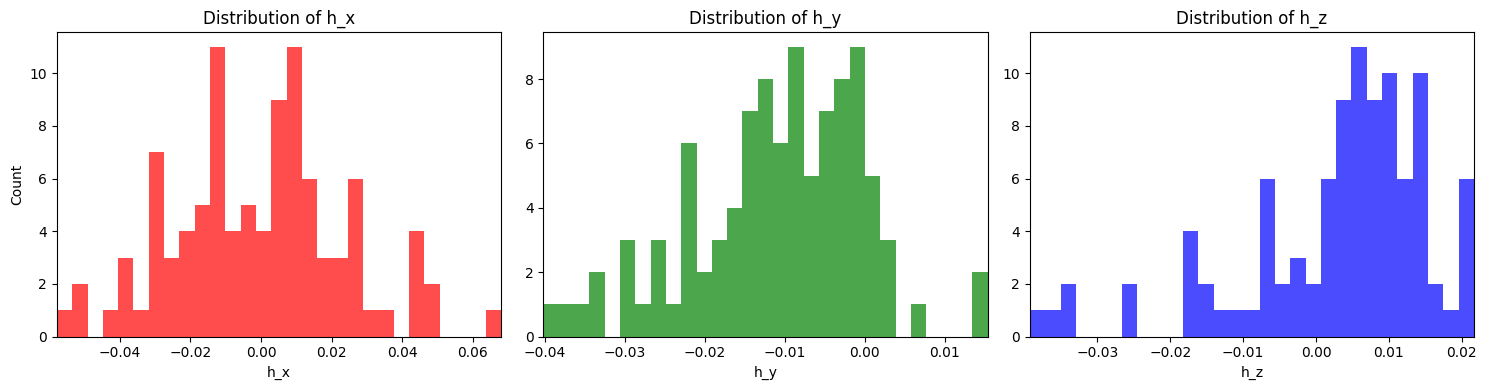

x_mean = -0.0005825158817275213
y_mean = -0.010907879351271398
z_mean = 0.002935747924171593
x_std = 0.02390974360868124
y_std = 0.010669606051795568
z_std = 0.012960788559363374


In [45]:
%matplotlib inline
# 改為畫出直方圖（histogram）
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 移除 nan 值
hx_clean = [h for h in hx_list if not np.isnan(h)]
hy_clean = [h for h in hy_list if not np.isnan(h)]
hz_clean = [h for h in hz_list if not np.isnan(h)]

# 自動計算範圍
hx_min, hx_max = min(hx_clean), max(hx_clean)
hy_min, hy_max = min(hy_clean), max(hy_clean)
hz_min, hz_max = min(hz_clean), max(hz_clean)

# 依據範圍自動切 bins（你也可以設固定數量，如 bins=50）
hx_bins = np.linspace(hx_min, hx_max, 30)
hy_bins = np.linspace(hy_min, hy_max, 30)
hz_bins = np.linspace(hz_min, hz_max, 30)

# 畫 histogram
ax[0].hist(hx_clean, bins=hx_bins, color='r', alpha=0.7)
ax[0].set_xlabel("h_x")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of h_x")
ax[0].set_xlim(hx_min, hx_max)

ax[1].hist(hy_clean, bins=hy_bins, color='g', alpha=0.7)
ax[1].set_xlabel("h_y")
ax[1].set_title("Distribution of h_y")
ax[1].set_xlim(hy_min, hy_max)

ax[2].hist(hz_clean, bins=hz_bins, color='b', alpha=0.7)
ax[2].set_xlabel("h_z")
ax[2].set_title("Distribution of h_z")
ax[2].set_xlim(hz_min, hz_max)

plt.tight_layout()
plt.show()
print(f"x_mean = {np.mean(hx_clean)}")
print(f"y_mean = {np.mean(hy_clean)}")
print(f"z_mean = {np.mean(hz_clean)}")
print(f"x_std = {np.std(hx_clean)}")
print(f"y_std = {np.std(hy_clean)}")
print(f"z_std = {np.std(hz_clean)}")